In [2]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


In [3]:
pip install nba_api


Note: you may need to restart the kernel to use updated packages.


In [2]:
from nba_api.stats.endpoints import playergamelog
from nba_api.stats.static import players
import pandas as pd
import time

target_players = ['Stephen Curry', 'Brandin Podziemski', 'Jimmy Butler III']
results = {}

def get_player_id(name):
    player = [p for p in players.get_players() if p['full_name'] == name]
    return player[0]['id'] if player else None

for name in target_players:
    player_id = get_player_id(name)
    if player_id is None:
        continue
    time.sleep(1)
    log = playergamelog.PlayerGameLog(player_id=player_id, season='2024-25', season_type_all_star='Regular Season')
    df = log.get_data_frames()[0].head(10)
    df['FGA'] = df['FGA'].replace(0, 1)
    df['TSA'] = df['FGA'] + 0.44 * df['FTA']
    df['TS%'] = df['PTS'] / (2 * df['TSA'])
    df['AST%'] = df['AST'] / df['MIN'].replace(0, 1)
    df['TOV%'] = df['TOV'] / df['MIN'].replace(0, 1)
    results[name] = df[['TS%', 'AST%', 'TOV%']].iloc[::-1].reset_index(drop=True)


In [4]:
df.to_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/4번 시각화/top 3 players.csv", index=False, encoding='utf-8-sig')

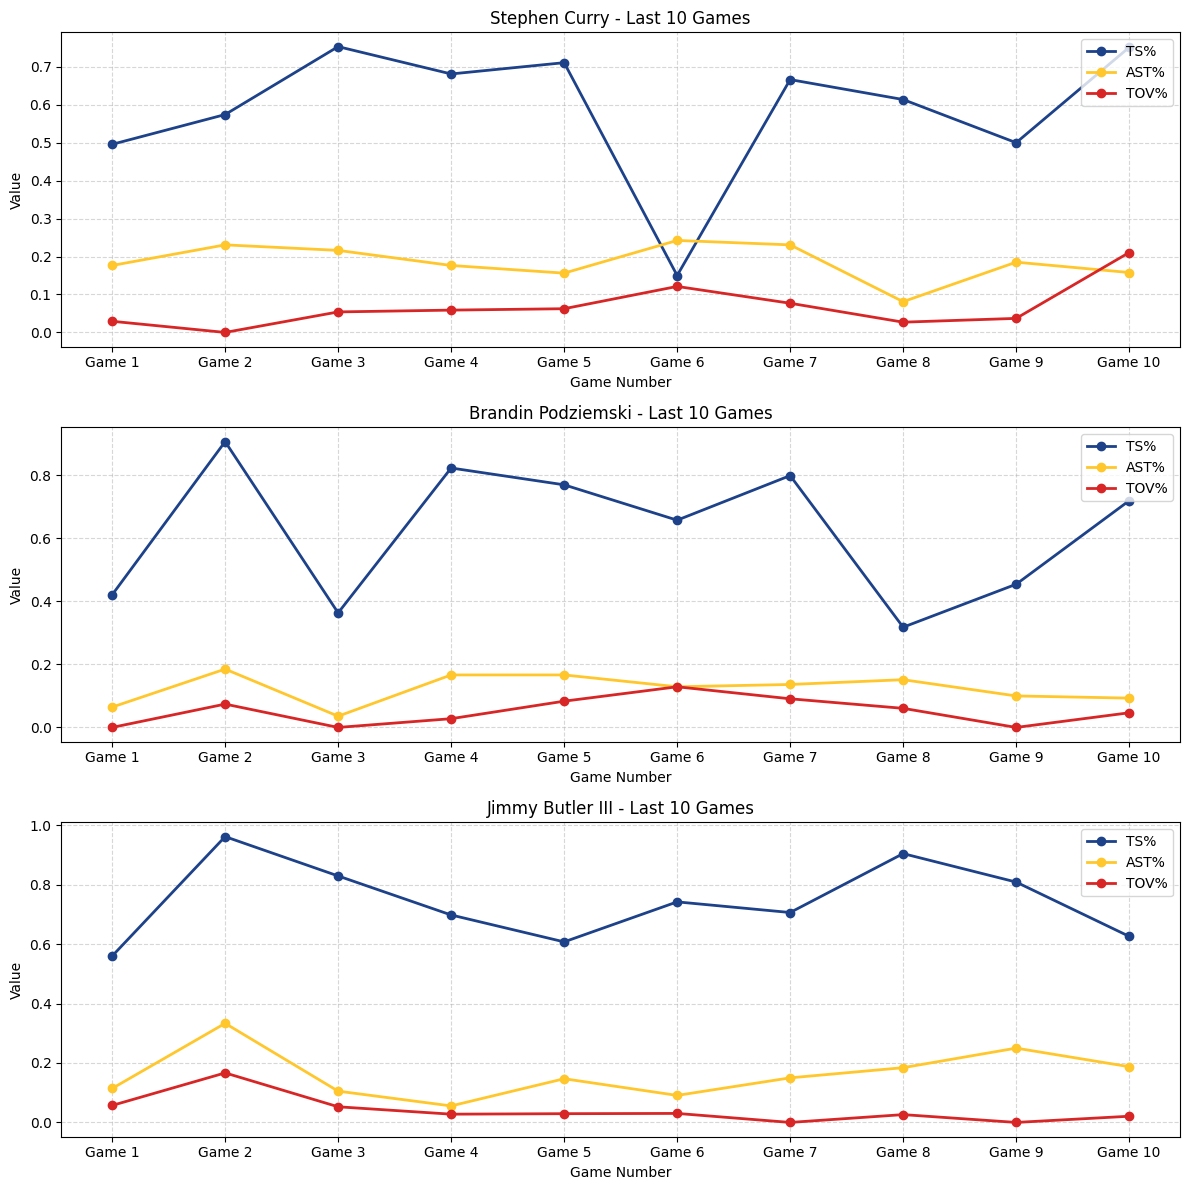

In [24]:
import matplotlib.pyplot as plt

plt.style.use('default')

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=False)

players = ['Stephen Curry', 'Brandin Podziemski', 'Jimmy Butler III']
metrics = ['TS%', 'AST%', 'TOV%']
colors = ['#1D428A', '#FFC72C', '#D82626']
games = list(range(1, 11))

for ax, player in zip(axes, players):
    df = results[player]
    for metric, color in zip(metrics, colors):
        ax.plot(games, df[metric], marker='o', linewidth=2, label=metric, color=color)
    ax.set_title(f'{player} - Last 10 Games', fontsize=12)
    ax.set_ylabel('Value')
    ax.set_xlabel('Game Number')  # ✅ 모든 subplot에 x축 라벨 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')
    ax.set_facecolor('white')
    ax.set_xticks(games)
    ax.set_xticklabels([f'Game {g}' for g in games], fontsize=10)

plt.tight_layout()
plt.show()
